![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

In [58]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [59]:
penguins_df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,332.000000,332.000000,332.000000,332.000000
mean,44.021084,17.153012,200.975904,4206.475904
std,5.452462,1.960275,14.035971,806.361278
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.700000,17.300000,197.000000,4025.000000
75%,48.625000,18.700000,213.000000,4781.250000
max,59.600000,21.500000,231.000000,6300.000000


In [60]:
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB


**Data Cleaning**

In [61]:
#Defining feature types
penguins_df['sex']  = penguins_df['sex'].astype('category')
penguins_clean = penguins_df.copy()

#Encoding/mapping categorical features
map = {'MALE' : 0,
       'FEMALE': 1}
penguins_clean['female'] = penguins_clean['sex'].replace(map)

#Dropping text features and keeping only numerical and encoded features
penguins_clean.drop('sex', axis = 1, inplace = True)
penguins_clean.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,female
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,1
2,40.3,18.0,195.0,3250.0,1
3,36.7,19.3,193.0,3450.0,1
4,39.3,20.6,190.0,3650.0,0


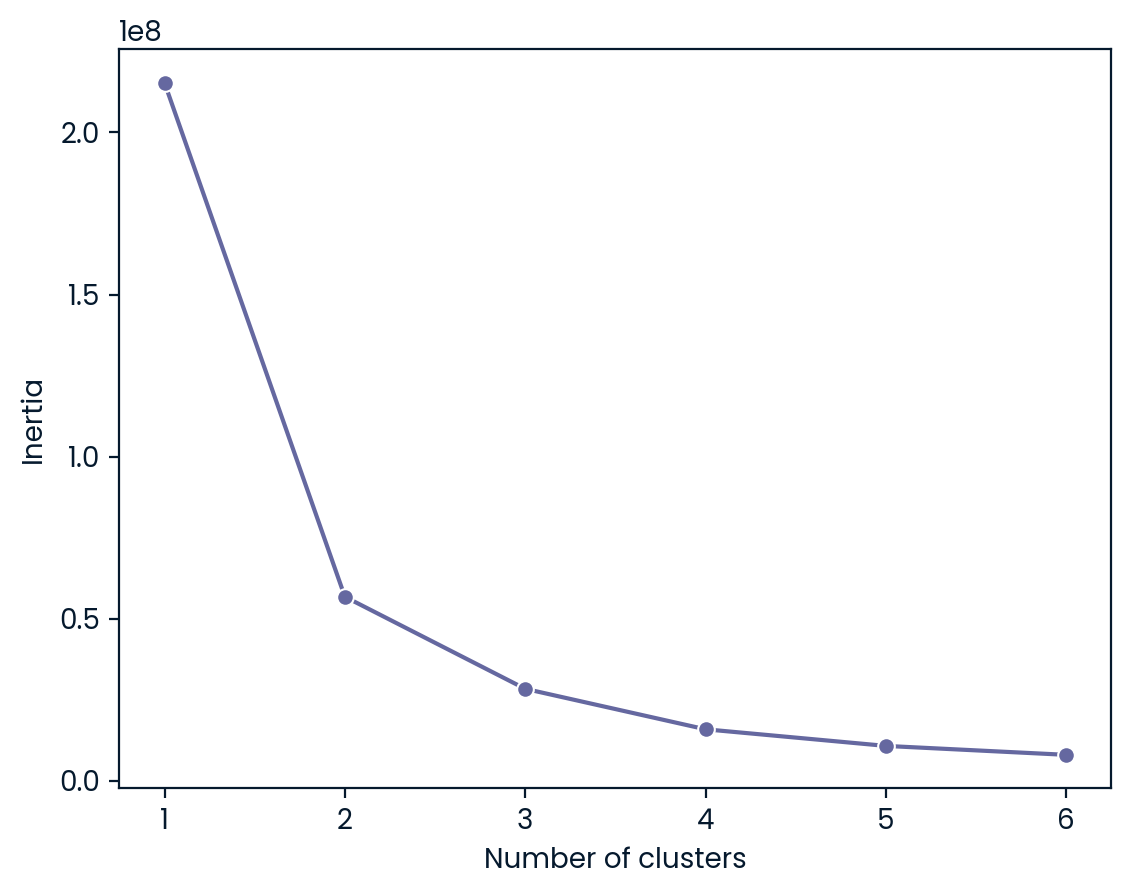

In [62]:
#Elbow test to determine ideal number of clusters

nclusters = range(1,7)
inertias = []
for n in nclusters: 
    model = KMeans(n)
    model.fit(penguins_clean)
    inertia = model.inertia_
    inertias.append(inertia)

sns.lineplot(x = nclusters, y = inertias, marker = 'o')
plt.xlabel("Number of clusters")
plt.ylabel('Inertia')
plt.show()

**Model fitting and transformation**

In [63]:
scaler = StandardScaler()
model = KMeans(n_clusters = 3)

#Preprocessing- normalization
scaler.fit(penguins_clean)
penguins_scaled = scaler.transform(penguins_clean)

#Clustering
labels = model.fit_predict(penguins_scaled)

penguins_clustered = penguins_df.copy()
penguins_clustered['cluster'] = labels
penguins_clustered.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,39.1,18.7,181.0,3750.0,MALE,2
1,39.5,17.4,186.0,3800.0,FEMALE,1
2,40.3,18.0,195.0,3250.0,FEMALE,1
3,36.7,19.3,193.0,3450.0,FEMALE,1
4,39.3,20.6,190.0,3650.0,MALE,2


**Cluster statistics**

In [64]:
stat_penguins = penguins_clustered.groupby('cluster').mean()
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,47.568067,14.996639,217.235294,5092.436975
1,40.217757,17.611215,189.046729,3419.158879
2,43.878302,19.111321,194.764151,4006.603774
